In [1]:
import pandas

In [2]:
# Importing all cleaned datasets
df_usagers = pandas.read_csv("df_usagers_clean.csv")
df_caract = pandas.read_csv("df_caract_clean.csv")
df_lieux = pandas.read_csv("df_lieux_clean.csv")
df_vehicules = pandas.read_csv("df_vehicules_clean.csv")

In [3]:
df_main = df_usagers.merge(df_vehicules, on = ['Num_Acc', 'id_vehicule'], how='left')
df_main = df_main.merge(df_caract, on = ['Num_Acc'], how = 'left')
df_main = df_main.merge(df_lieux, on = ['Num_Acc'], how = 'left')

In [4]:
df_main.dropna(inplace = True)

In [5]:
df_main.to_csv("df_clean.csv", index=False)

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Usagers
categorical_features_usagers = ['place', 'catu', 'sexe', 'trajet',
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'gants_airbag', 'autre']
numerical_features_usagers = ["age"]

# Caract
categorical_features_caract = ['lum', 'agg', 'int', 'atm', 'col']
numerical_features_caract = ['lat', 'long', 'day_sin', 'day_cos', 'hour_sin', 'hour_cos']

# Lieux
categorical_features_lieux = ['catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'surf', 'infra', 'situ', 'vma']

# Vehicule
categorical_features_vehicules = ['catv', 'obs', 'obsm', 'choc', 'manv', 'motor'] 

num_features = numerical_features_usagers + numerical_features_caract
cat_features = categorical_features_usagers + categorical_features_caract + categorical_features_lieux + categorical_features_vehicules

features = num_features + cat_features
target = "grav_bin"

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

preprocessor_cat_only = ColumnTransformer(
    transformers=[
        ("cat", "passthrough", cat_features)
    ],
    remainder="drop"
)

In [23]:
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

X = df_main[features]
y = df_main[target]

rus = RandomUnderSampler()
X_resampled, y_resampled = rus.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,
    random_state=42
)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )

In [24]:
from sklearn.naive_bayes import CategoricalNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = {
    # "Categorical NB": CategoricalNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

pipelines = {}

for name, model in models.items():
    if name == "Categorical NB":
        prep = preprocessor_cat_only
    else:
        prep = preprocessor

    pipelines[name] = Pipeline([
        ("preprocessing", prep),
        ("model", model)
    ])

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

for name, pipe in pipelines.items():

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1]

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


 Logistic Regression
Accuracy: 0.7689065160513311
              precision    recall  f1-score   support

           0       0.78      0.75      0.76     23909
           1       0.76      0.79      0.78     24249

    accuracy                           0.77     48158
   macro avg       0.77      0.77      0.77     48158
weighted avg       0.77      0.77      0.77     48158


 Decision Tree
Accuracy: 0.7303459445990282
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     23909
           1       0.73      0.73      0.73     24249

    accuracy                           0.73     48158
   macro avg       0.73      0.73      0.73     48158
weighted avg       0.73      0.73      0.73     48158


 Gradient Boosting
Accuracy: 0.7816769799410275
              precision    recall  f1-score   support

           0       0.80      0.75      0.77     23909
           1       0.77      0.81      0.79     24249

    accuracy                         

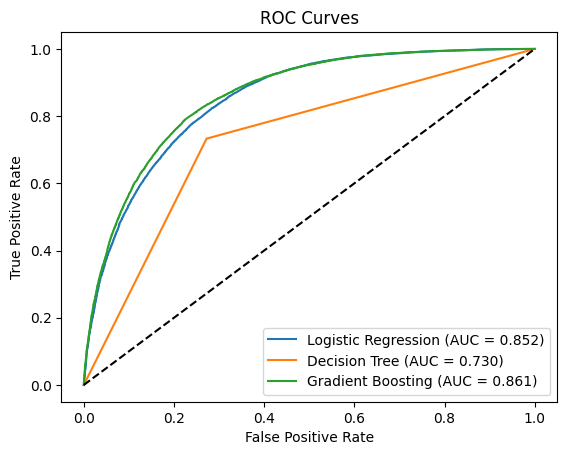

In [26]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for name, pipe in pipelines.items():

    y_proba = pipe.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

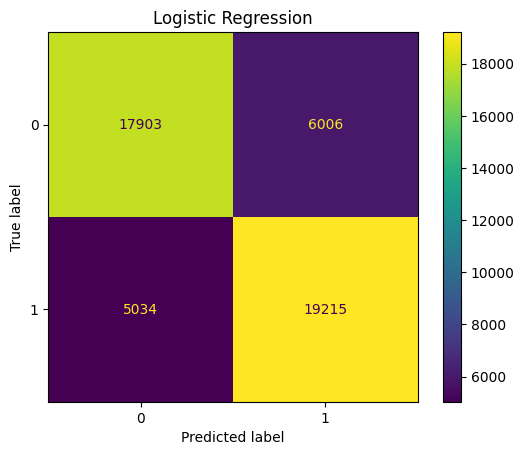

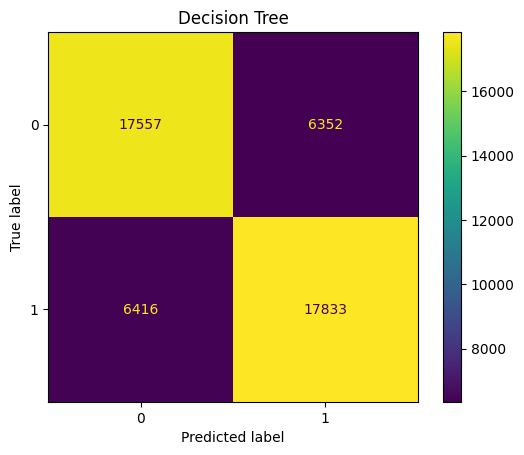

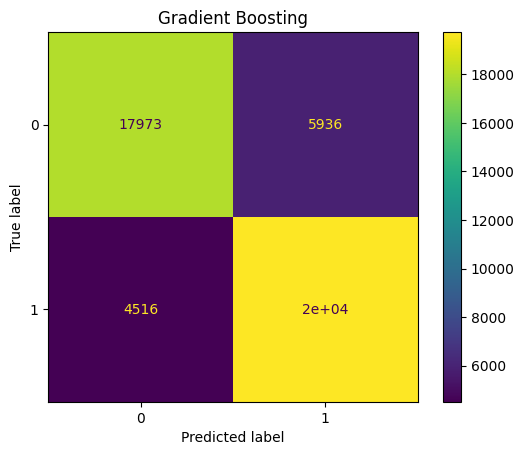

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()